# Task 2: Weight init diagnostics (gradient vanishing/exploding)

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)


In [2]:
def xavier_init(fan_in, fan_out):
    limit = (6/(fan_in+fan_out))**0.5
    return (torch.rand(fan_in, fan_out)*2 - 1) * limit

def kaiming_init(fan_in, fan_out):
    std = (2/fan_in)**0.5
    return torch.randn(fan_in, fan_out) * std

def build_layers(sizes, init_fn):
    layers = []
    for i in range(len(sizes)-1):
        W = init_fn(sizes[i], sizes[i+1])
        W.requires_grad_(False)
        layers.append(W)
    return layers


In [3]:
def forward_track(x, layers):
    stats = []
    a = x
    for W in layers:
        z = a @ W
        a = torch.relu(z)
        stats.append((a.mean().item(), a.var().item()))
    return a, stats

sizes = [256]*21
x = torch.randn(64, 256)


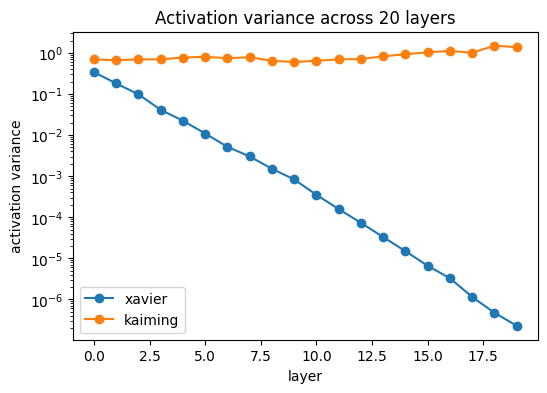

In [4]:
plt.figure(figsize=(6,4))
for name, fn in [("xavier", xavier_init), ("kaiming", kaiming_init)]:
    layers = build_layers(sizes, fn)
    _, stats = forward_track(x, layers)
    variances = [s[1] for s in stats]
    plt.plot(variances, marker="o", label=name)

plt.xlabel("layer")
plt.ylabel("activation variance")
plt.yscale("log")
plt.title("Activation variance across 20 layers")
plt.legend()
plt.show()
